# Ising sampling and contrastive divergence


<div class="note"><span class="note-t">In brief</span>
<p>We compare Torx chromatic Gibbs sampling with a host sampler that walks Torx-generated <code>PISING</code> matrices, one bond kernel per ring edge, where a bond kernel is a two-spin transition matrix carrying only the energy of its own edge. Because a bond kernel never sees the spin sitting just outside its edge, the comparison prices that omitted-neighbor bias: the host walk sits at total variation 0.4020 from the exact law against 0.0634 for chromatic Gibbs. We then fit the ring with persistent contrastive divergence that is host-only, meaning it runs in notebook NumPy from start to finish rather than through Torx, and it recovers every coupling and field to within 0.05.</p>
</div>

In this tutorial, we study Ising sampling with Torx's single-site and bond-local kernels.

An [**Ising model**](https://www.scholarpedia.org/article/Ising_model) is a graph with a coupling on every edge and a field at every site. It defines the Boltzmann distribution $\pi(\mathbf{s}) \propto e^{-\beta H(\mathbf{s})}$ over all $2^N$ spin configurations, and that distribution is the target every sampler in this notebook is trying to reproduce.

This is also a Boltzmann machine ([Ackley et al. 1985](#ref-ackley)): a network whose joint distribution is set by pairwise couplings and per-site biases. So the same object serves twice here, first as something to sample from and later as something to learn.

Locality makes fast sampling possible. Each spin's conditional depends only on its graph neighbors, so a whole color class of conditionally independent sites can update at once. This parallel single-site sampler is **chromatic Gibbs sampling**.

Three experiments follow, and each answers a different question.

First, does one site behave like the ideal Gibbs conditional when we run it as a real circuit? We build a small probe from Torx's reset and conditional-flip operations, `PReset` and `PNOT`, run it on the `BranchingSimulator`, and check its sampled mean against a target probability. The reset strength is finite rather than infinite, so the probe tests a close approximation of the ideal update instead of the ideal update itself.

Second, does a full ring sampler reproduce the Boltzmann law? We answer this twice over, with two samplers that are both local but local in different ways. One runs every single-site draw through Torx as a manual-zero `PNOT` update, which hands the gate an exact zero state instead of resetting it. The other stays bond-local: it asks Torx to generate one two-spin transition matrix per edge with `PISING`, then walks those matrices on the host. Because the 8-site ring is small enough to enumerate all $2^8 = 256$ states, we have an exact Boltzmann reference and the gap between the two samplers becomes a measurement rather than an argument.

That gap is where the interesting failure lives. A bond matrix carries its own bond energy and half of each endpoint's field, but it cannot see the live energy each endpoint shares with its neighbor outside the pair, so the resulting pair update is not conditioned on the rest of the ring. Composing eight such updates therefore need not obey [detailed balance](https://en.wikipedia.org/wiki/Detailed_balance) for the global Boltzmann distribution, the condition that every pair of configurations exchanges probability equally in both directions, which is what pins a sampler to its target. The moment comparison makes that bias visible.

Third, can we recover the parameters from data? We fit the couplings and fields with persistent contrastive divergence. That fit is host-only: it runs in notebook NumPy, and Torx's contribution to it is the earlier evidence that the same update rule samples correctly.

<details class="tx-disclosure"><summary>What runs where?</summary><ul><li>Torx: the finite-reset probe and every chromatic-Gibbs site draw.</li><li>Notebook code: exact enumeration, <code>PISING</code> matrix construction, moments, and parameter updates.</li><li><code>examples/helpers/_plots_sampling.py</code>: the Torx chromatic loop, host <code>PISING</code> matrix walker, and host PCD loop.</li></ul></details>

By the end, you'll be able to:

- distinguish the ideal infinite reset from the finite probe and the ring's manual-zero implementation,
- compare Torx chromatic Gibbs with host sampling from Torx-generated `PISING` matrices against an exact 8-site reference, and
- fit Ising parameters with host-only persistent contrastive divergence.

## Setup

We set up the helper path, imports, shared plotting style, and figure-saving utility.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
# Locate helpers whether the notebook runs from examples/ or a subdirectory of it.
if not (ROOT / "helpers").exists() and (ROOT.parent / "helpers").exists():
    ROOT = ROOT.parent
HELPER_DIR = ROOT / "helpers"
sys.path.insert(0, str(HELPER_DIR))

With the helper path set, we import Torx, the numerical libraries, and the notebook helpers:

In [2]:
import jax
import jax.numpy as jnp
import numpy as np

from _notebook_paths import figure_dir
from _notebook_style import (
    apply_notebook_style,
    make_savefig,
)
import _plots_sampling as P_samp
import _plots_schematics as P_sch

from torx.psc import (
    DiscretePCircuit,
    PISING,
    PNOT,
    PReset,
    BranchingSimulator,
)

We apply the shared style, fix `SEED` so every draw below is reproducible, and wrap figure export:

In [3]:
apply_notebook_style()
FIGURE_DIR = figure_dir(ROOT)
SEED = 123
rng = np.random.default_rng(SEED)


savefig = make_savefig(FIGURE_DIR)

## The Ising model

Before any Torx call, we fix the two objects the rest of the notebook keeps referring back to: the energy of a spin configuration, and the one-site conditional a Gibbs sampler draws from.

A spin configuration $\mathbf{s} \in \{-1, +1\}^N$ has energy

$$
H(\mathbf{s}) = \underbrace{-\sum_{(i,j)\in E} J_{ij}\, s_i s_j}_{\vphantom{\big|}\text{bond energy}} \;\underbrace{-\sum_i h_i\, s_i}_{\vphantom{\big|}\text{field energy}} ,
$$

where the first sum runs over the edges $E$ and the second over the sites. The Boltzmann distribution at inverse temperature $\beta$ is

$$
\pi(\mathbf{s}) \propto e^{-\beta H(\mathbf{s})} .
$$

Because the energy is a sum of purely local terms, we never have to touch the whole configuration at once. Single-site Gibbs sampling resamples one spin at a time from its exact conditional. For site $i$ with neighbors $N(i)$, we write the local field

$$
\ell_i = h_i + \underbrace{\sum_{j \in N(i)} J_{ij}\,(2\sigma_j - 1)}_{\vphantom{\big|}\text{neighbor sum}},
\qquad
\pi(\sigma_i = 1 \mid \sigma_{N(i)}) = \frac{1}{1 + e^{-2\beta\ell_i}} ,
$$

using bits $\sigma \in \{0, 1\}$ with $s = 2\sigma - 1$. The neighbor sum runs only over $N(i)$.

The conditional is a Bernoulli whose logit (the log-odds of the spin being up) is $2\beta\ell_i$, and this one-site conditional is all the sampler needs. Everything that follows is a question about how faithfully some piece of machinery reproduces it.

## The per-site update

Our first job is to get one site right, because a ring sampler is only as trustworthy as the single update it repeats. An ideal Gibbs update discards the current spin, then draws a Bernoulli bit from the conditional above. In Torx notation that identity is

$$
\mathsf{PColor}_i = \mathsf{PNOT}(2\beta\ell_i) \circ \mathsf{PReset}(\infty).
$$

That identity is stated with an infinite reset, which no circuit can execute, so the notebook works with three distinct reset cases in total. We name all three now, because later sections refer back to this list:

1. **The ideal infinite reset**, `PReset(∞)`, which appears in the identity above and is a mathematical statement rather than something we run.
2. **The finite reset**, `PReset(12.0)`, used by the probe in this section. It drives the input close to zero rather than exactly to zero, so it tests a close approximation of case 1 with a small reset-leak contribution.
3. **The ring's manual zero**, used from the chromatic Gibbs section onward. It supplies an exact zero initial state and applies only `PNOT`, so it uses no reset gate at all and leaks nothing.

For the finite probe, choose a target probability $p = 0.73$:

In [4]:
# Choose a target Bernoulli probability for the one-pbit check.
p_one = 0.73

# Gates carry only their site index; parameters live in `probe_thetas`,
# aligned with the gate order: PReset drives strongly to 0, then PNOT flips
# with probability sigmoid(logit) = p_one.
probe_kernel = DiscretePCircuit(
    [
        PReset(0),
        PNOT(0),
    ]
)
probe_thetas = [
    jnp.array([12.0]),
    jnp.array([float(np.log(p_one / (1.0 - p_one)))]),
]

We draw the probe circuit first, so the executable shape of case 2 is visible before we sample from it:

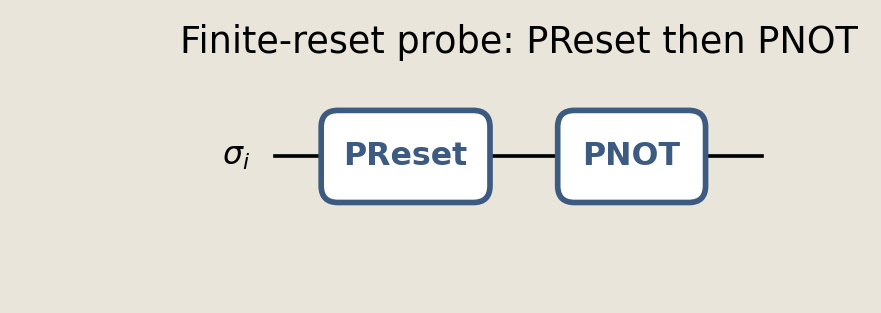

In [5]:
fig_probe = P_sch.draw_pcircuit(
    probe_kernel,
    wire_labels=[r"$\sigma_i$"],
    title="Finite-reset probe: PReset then PNOT",
)
savefig(fig_probe, "06_site_update_circuit")

Two gates on one wire is the whole probe: the finite reset drives $\sigma_i$ close to zero, then `PNOT` resamples it at the conditional's log-odds.

The claim to test is that this approximation is already good enough to stand in for the ideal identity. We draw 2000 samples and compare the empirical mean against the target `p_one` with a tolerance of `0.04`, so agreement at that level tells us the reset leak is too small to matter at the resolution we sample it:

In [6]:
probe_sim = BranchingSimulator(num_samples=2000)
probe_circuit = probe_sim.build_circuit(probe_kernel, probe_thetas)
probe = float(
    np.asarray(
        probe_sim.sample(
            probe_circuit, jnp.array([1], dtype=jnp.int32), jax.random.key(SEED)
        )
    ).mean()
)

np.testing.assert_allclose(probe, p_one, atol=0.04)
print(f"target p = {p_one:.2f}  |  sampled mean = {probe:.3f}")

target p = 0.73  |  sampled mean = 0.741


## Chromatic Gibbs sampling on a ring

With one site validated, we scale the same update out to a whole graph. The ring has $N = 8$ sites, one pbit per site, one $J_{ij}$ per edge, and one $h_i$ per site.

We color the sites by parity: evens in one color, odds in the other. No neighboring sites share a color, so all sites of one color can update at once while conditioned on the other color.

In [7]:
N = 8
beta = 1.5
ring_edges = [(i, (i + 1) % N) for i in range(N)]
J_true = np.array([0.65, -0.40, 0.55, 0.45, -0.35, 0.50, 0.30, -0.45])
h_true = np.array([0.10, -0.15, 0.05, 0.12, -0.10, 0.08, -0.04, 0.02])
colors = [np.arange(0, N, 2), np.arange(1, N, 2)]

Every comparison from here on needs a ground truth, so we enumerate all 256 states to build the exact Boltzmann reference and its moments:

In [8]:
def state_index(bits):
    # Map each bit row to the histogram bin used by np.bincount.
    return bits @ (2 ** np.arange(N - 1, -1, -1))


# Enumerate bit states so the exact reference is available for comparison.
states = ((np.arange(2**N)[:, None] >> np.arange(N - 1, -1, -1)) & 1).astype(int)
spins = 2 * states - 1
energy = (
    -np.array(
        [J_true[e] * spins[:, i] * spins[:, j] for e, (i, j) in enumerate(ring_edges)]
    ).sum(0)
    - spins @ h_true
)
exact = np.exp(-beta * energy)
exact /= exact.sum()
exact_mag = (exact[:, None] * spins).sum(axis=0)
exact_corr = np.array(
    [float((exact * spins[:, i] * spins[:, j]).sum()) for (i, j) in ring_edges]
)

np.testing.assert_allclose(exact.sum(), 1.0, atol=1e-10)
print(f"exact Boltzmann: {len(exact)} states, peak = {exact.max():.4f}")

exact Boltzmann: 256 states, peak = 0.0700


Before running the sweep, we draw the ring to see why two colors are enough:

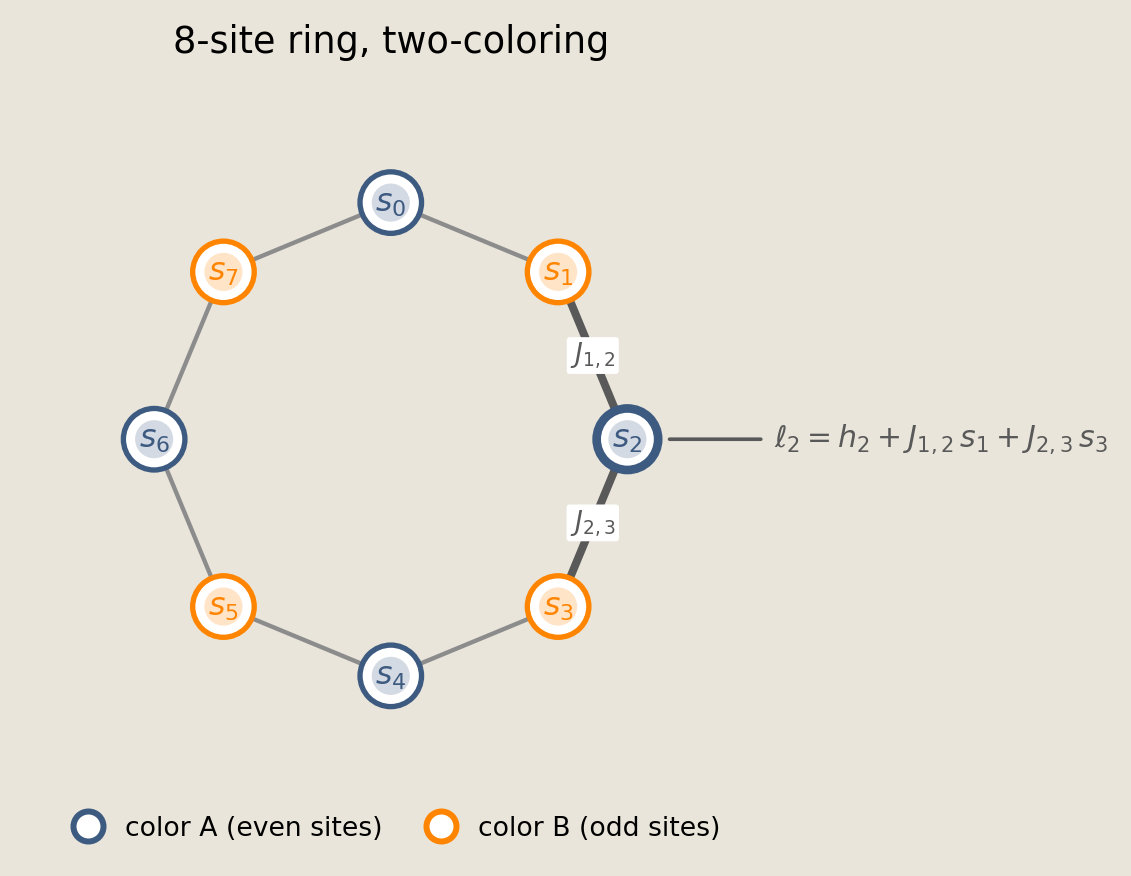

In [9]:
fig = P_sch.plot_chromatic_ring(N=N, ring_edges=ring_edges, colors=colors)
savefig(fig, "06_chromatic_ring")

The even and odd classes carry distinct outlines and never touch, which is what lets a whole class update in parallel, and the dark incident edges marking the local field for $s_2$ show how narrow each conditional is: a site only reads its two ring neighbors.

We now run the sampler itself: 6000 independent chains for 240 sweeps with `torx_chromatic_gibbs` in `examples/helpers/_plots_sampling.py`. This is case 3 from the reset list above, the ring's manual zero. Every site update supplies an exact zero state to a one-gate Torx `PNOT` circuit on `BranchingSimulator`, and because it does not execute `PReset`, there is no finite-reset leakage to account for here.

Its claim-bearing core is:

```python
def torx_chromatic_gibbs(init_bits, J, h, *, N, beta, colors, sweeps, key):
    ...
    sim = BranchingSimulator(num_samples=1)
    base = sim.build_circuit(
        DiscretePCircuit([PNOT(0)]),
        [jnp.array([0.0])],
    )

    def sample_bit(logit, bit_key):
        thetas = base.thetas.at[0, 0].set(logit)
        circ = eqx.tree_at(lambda c: c.thetas, base, thetas)
        out = sample_circuit(
            circ, jnp.zeros(1, dtype=jnp.int32), bit_key, num_samples=1
        )[0]
        return out[0, 0]

    sample_bits = jax.vmap(sample_bit)
```

Each chain's conditional logit $2\beta\ell_i$ is folded into the `PNOT` gate theta and `sample_bit` is vmapped over every chain and color site, so one batched Torx call draws an entire color class. We then compare the empirical distribution and moments with the exact reference through total variation distance, which measures how far apart two distributions are, and we require it to come in under 0.08:

In [10]:
num_chains = 6000
# Start many independent chains so the histogram estimate is stable.
chains = rng.integers(0, 2, size=(num_chains, N))
# Every single-site update is sampled through the Torx PNOT-from-zero kernel.
gibbs_samples = P_samp.torx_chromatic_gibbs(
    chains,
    J_true,
    h_true,
    N=N,
    beta=beta,
    colors=colors,
    sweeps=240,
    key=jax.random.key(SEED),
)

empirical = np.bincount(state_index(gibbs_samples), minlength=2**N) / num_chains
tv_distance = 0.5 * np.abs(empirical - exact).sum()
gibbs_mag, gibbs_corr = P_samp.moments(gibbs_samples, ring_edges)

assert tv_distance < 0.08, f"TV = {tv_distance:.4f} (expected < 0.08)"
print(f"Torx chromatic Gibbs TV from exact Boltzmann = {tv_distance:.4f}  (< 0.08)")

Torx chromatic Gibbs TV from exact Boltzmann = 0.0634  (< 0.08)


## Host sampling from Torx-generated PISING matrices

Chromatic Gibbs is one way to be local. This section builds the other, so that we can measure what changes when locality is drawn around a bond instead of a site. The bond-local alternative updates one edge at a time.

The Torx `PISING` operation, constructed as `PISING([i, j])` with theta `[J, h_i, h_j, beta, dt]`, generates a column-stochastic Glauber matrix for the two incident spins. Column-stochastic means every column of transition probabilities sums to one. Its transition matrix is

$$
P = \exp(Q\,\Delta t),
$$

where $Q$ is the single-spin-flip generator of the bond energy $E(s_i, s_j) = -J s_i s_j - h_i s_i - h_j s_j$. Here $\Delta t$ is `pising_dt` in the next cell.

We generate one matrix for each ring edge and split each site's field in half so its two incident bonds sum to $h_i$. The fields therefore add up correctly, but these two-spin matrices still omit the live energy contribution from the external neighbor of each endpoint. A block-Gibbs pair update would condition on those neighbors, and this bond matrix does not, so the composed host walk need not preserve the ring Boltzmann law, meaning the distribution the walk would leave unchanged once mixed is not guaranteed to be the one we want.

In [11]:
pising_dt = 0.45

# Gates are structure only (site pair); the [J, h1, h2, beta, dt] parameters
# live in `ring_pising_thetas`, aligned with the gates. Split each site field
# across the two bonds that touch it so the incident bonds sum back to h_i.
ring_pising_gates = [PISING([int(i), int(j)]) for (i, j) in ring_edges]
ring_pising_thetas = [
    jnp.array([J_true[e], h_true[i] / 2.0, h_true[j] / 2.0, beta, pising_dt])
    for e, (i, j) in enumerate(ring_edges)
]

ring_mats = np.asarray(
    [
        np.asarray(g.get_matrix(theta))
        for g, theta in zip(ring_pising_gates, ring_pising_thetas)
    ]
)
# Each PISING gate is column-stochastic, so columns sum to one.
np.testing.assert_allclose(ring_mats.sum(axis=-2), 1.0, atol=1e-6)

We draw a representative slice of the bond sweep, the first three of eight gates for legibility, to show the gate structure the matrices come from. Torx's role at this stage is generation: we ask each `PISING` gate for its matrix and then sample on the host, so this circuit is never handed to a Torx simulator:

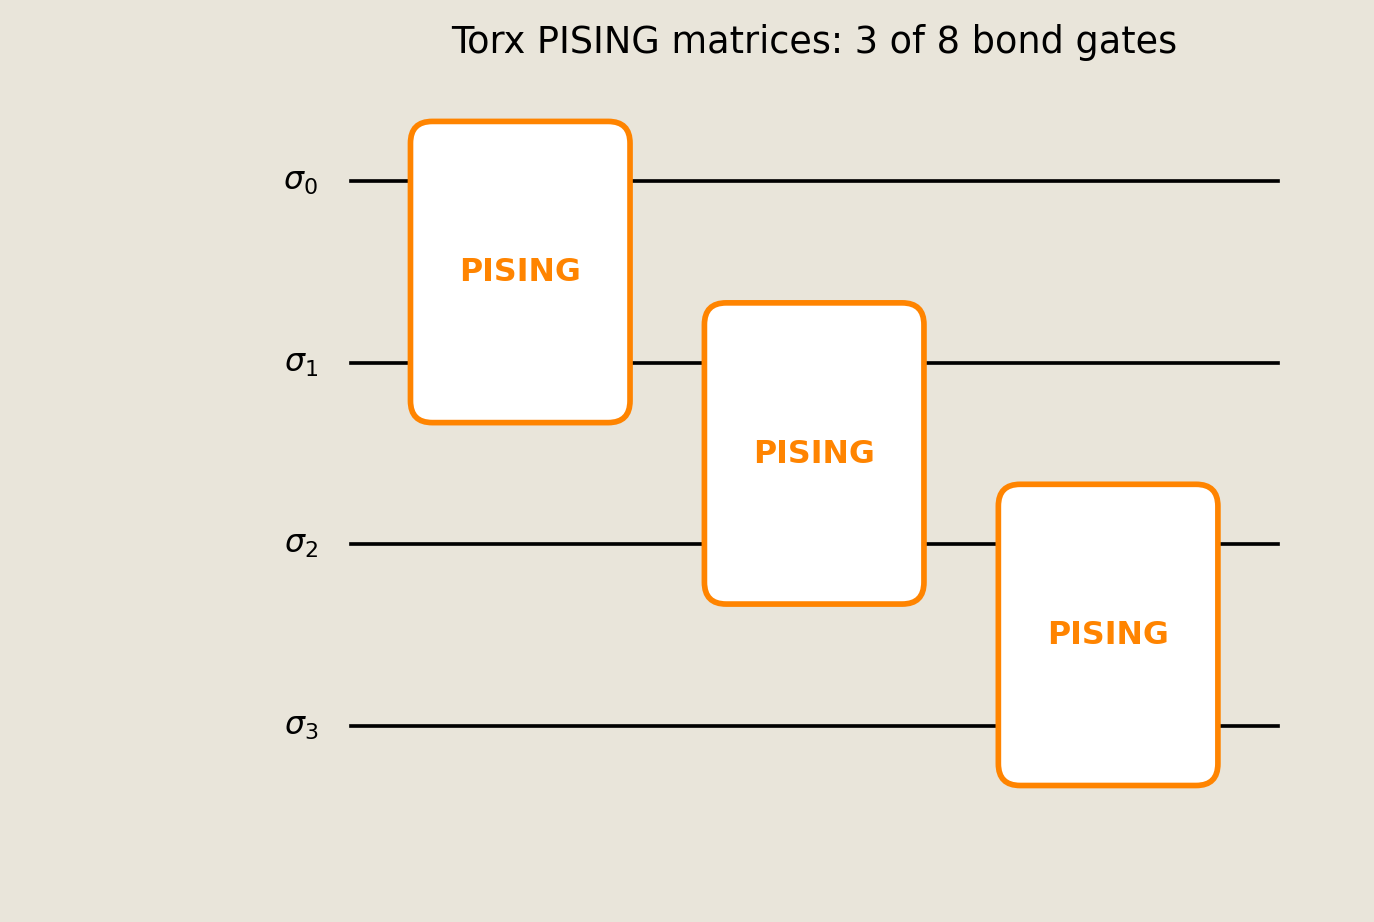

In [12]:
slice_gates = [PISING([e, e + 1]) for e in range(3)]
# no reps annotation: this is a 3-of-8 excerpt of one sweep, not the repeated unit
fig_pising = P_sch.draw_pcircuit(
    DiscretePCircuit(slice_gates),
    wire_labels=[rf"$\sigma_{i}$" for i in range(4)],
    title="Torx PISING matrices: 3 of 8 bond gates",
)
savefig(fig_pising, "06_pising_ring_circuit")

The full structural sweep places one two-spin bond gate on every ring edge, which is exactly the eight matrices assembled above.

To sample from those matrices we call `pising_ring_samples` in `examples/helpers/_plots_sampling.py`. It is a NumPy loop that walks each Torx-generated transition matrix in turn and draws the next pair state, returning the 4000 chains we need for the moment and total-variation comparisons:

In [13]:
pising_sweeps = 300
pising_num_chains = 4000
pising_samples = P_samp.pising_ring_samples(
    ring_mats,
    N=N,
    ring_edges=ring_edges,
    num_samples=pising_num_chains,
    sweeps=pising_sweeps,
    seed=SEED + 1,
)

pising_mag, pising_corr = P_samp.moments(pising_samples, ring_edges)
pising_hist = (
    np.bincount(state_index(pising_samples), minlength=2**N) / pising_num_chains
)
pising_tv = 0.5 * np.abs(pising_hist - exact).sum()

print(f"host walk of Torx PISING matrices TV from exact Boltzmann = {pising_tv:.4f}")
print(f"  chromatic Gibbs TV (for comparison)   = {tv_distance:.4f}")

host walk of Torx PISING matrices TV from exact Boltzmann = 0.4020
  chromatic Gibbs TV (for comparison)   = 0.0634


The distance puts a number on the difference. The host sampler using Torx-generated `PISING` matrices sits at total variation 0.4020 from the exact Boltzmann distribution, about six times the 0.0634 that Torx chromatic Gibbs reaches, and that ratio is what the omitted-neighbor bias costs.

### Comparing the moments

One distance tells us the samplers differ but not where, so we look at the statistics the difference lives in: the per-site magnetizations $\langle s_i\rangle$, the average spin at each site, and per-edge correlations $\langle s_i s_j\rangle$, the average neighboring-spin product. The panels place the exact reference, Torx chromatic Gibbs, and the host sampler using Torx-generated `PISING` matrices side by side. Torx chromatic Gibbs tracks the exact moments, while the host matrix walker gets most signs right but underestimates the magnitudes, far enough that at $s_6$, where the exact magnetization is nearly zero, even the sign flips.

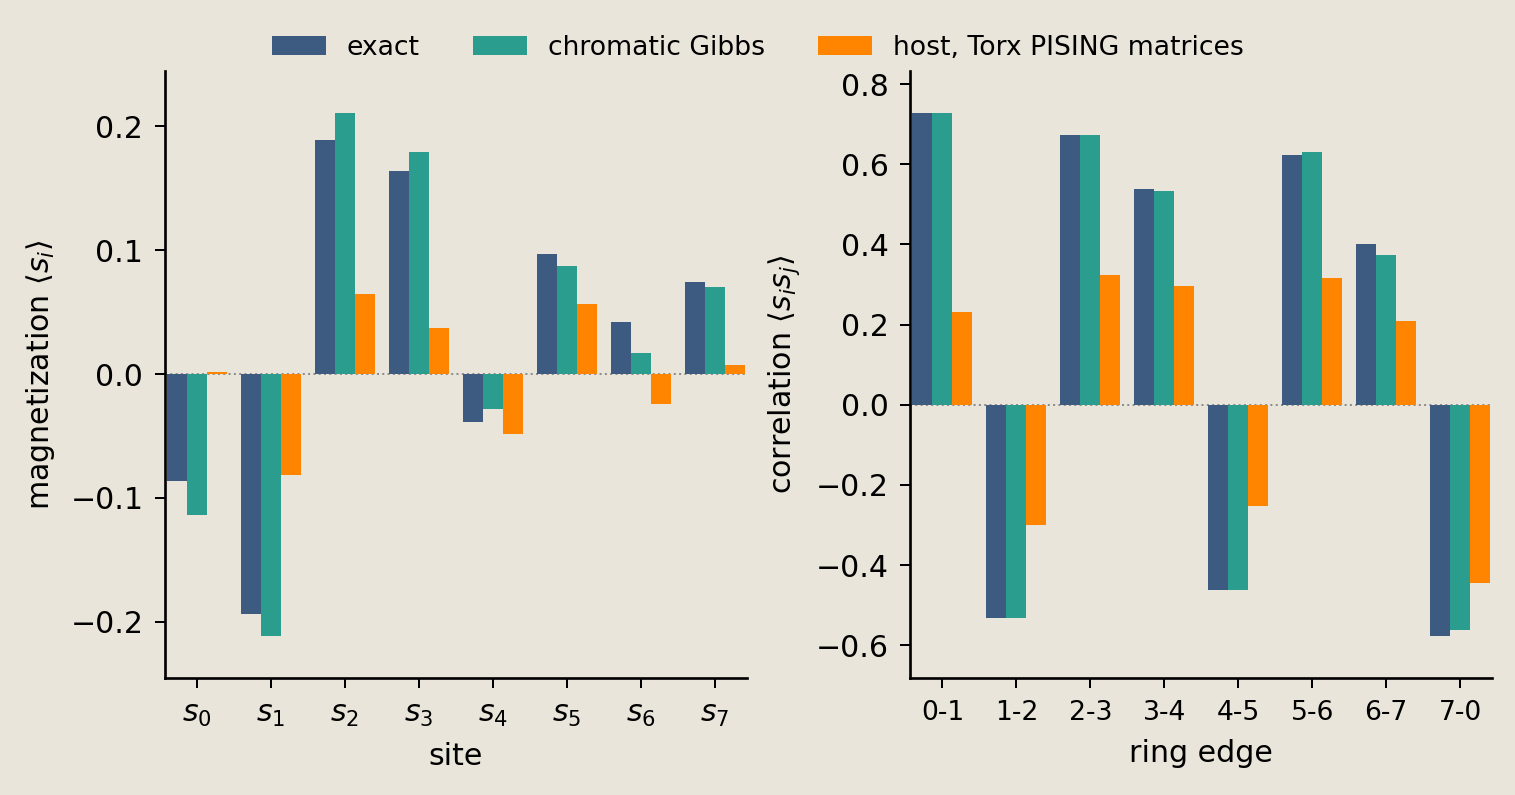

In [14]:
fig = P_samp.plot_ring_marginals(
    N=N,
    ring_edges=ring_edges,
    exact_mag=exact_mag,
    gibbs_mag=gibbs_mag,
    pising_mag=pising_mag,
    exact_corr=exact_corr,
    gibbs_corr=gibbs_corr,
    pising_corr=pising_corr,
)
savefig(fig, "06_ring_ising_marginals")

The smaller magnitudes are not a generic cost of local updates. Each bond matrix omits the current external-neighbor energy, so the pair transitions do not satisfy detailed balance for the full ring Boltzmann distribution. Chromatic Gibbs is also local, but its one-site conditional includes both live neighbors and preserves the target law.

## Host-only persistent contrastive divergence

So far the parameters were given and we sampled from them. Now we run that backwards: given samples, recover the parameters.

Contrastive divergence learns by comparison. It measures a few statistics of the data, measures the same statistics on samples the current model produces, and moves the parameters until the two agree. [**Persistent contrastive divergence** (Tieleman 2008)](#ref-tieleman) makes one change to that recipe: it keeps Gibbs chains running instead of resetting them from data, so at each step it contrasts the moments of long-lived chains with the data moments. The log-likelihood gradients are the moment differences:

$$
\partial_{J_{ij}}\log\mathcal{L} = \beta\bigl(\langle s_i s_j\rangle_{\text{data}} - \langle s_i s_j\rangle_{\text{model}}\bigr),
\qquad
\partial_{h_i}\log\mathcal{L} = \beta\bigl(\langle s_i\rangle_{\text{data}} - \langle s_i\rangle_{\text{model}}\bigr).
$$

Because the exact ring law is enumerable, we can draw honest training data from it directly: 2048 training samples from the exact Boltzmann distribution.

In [15]:
num_data = 2048
# dedicated stream so the fit is reproducible regardless of upstream sampler draws
fit_rng = np.random.default_rng(SEED)
# Draw synthetic data from the exact reference before fitting.
data_idx = fit_rng.choice(2**N, size=num_data, p=exact)
data_bits = states[data_idx]
data_mag, data_corr = P_samp.moments(data_bits, ring_edges)

We start the model deliberately uninformed, a flat $J = h = 0$, so whatever structure appears at the end came from the data and not from the initialization. The learning rate is $0.08$:

In [16]:
J = np.zeros(N)
h = np.zeros(N)
persistent = fit_rng.integers(0, 2, size=(num_data, N))
lr = 0.08

Each step calls the host NumPy `chromatic_gibbs` loop in `examples/helpers/_plots_sampling.py` for two sweeps, then the notebook updates $J$ and $h$ from the data-minus-model moment gap. This fit runs entirely on the host: Torx's contribution came earlier, when the chromatic sweep it executed reproduced the exact Boltzmann distribution to 0.0634 in total variation, which is what lets us use the fast NumPy mirror of the same update rule inside the training loop:

In [17]:
for step in range(300):
    # Keep persistent chains instead of resetting them to data each step. The fit
    # uses the fast host mirror of the kernel validated on Torx above.
    persistent = P_samp.chromatic_gibbs(
        persistent, J, h, N=N, beta=beta, colors=colors, sweeps=2, rng=fit_rng
    )
    model_mag, model_corr = P_samp.moments(persistent, ring_edges)
    h += lr * beta * (data_mag - model_mag)
    J += lr * beta * (data_corr - model_corr)

The claim is that 300 steps of this loop are enough to identify the model, so we compare every learned coupling and field against the true values that generated the data, with a tolerance of 0.05:

In [18]:
np.testing.assert_allclose(J, J_true, atol=0.05)
np.testing.assert_allclose(h, h_true, atol=0.05)
print(f"max |J_learned - J_true| = {np.max(np.abs(J - J_true)):.4f}")
print(f"max |h_learned - h_true| = {np.max(np.abs(h - h_true)):.4f}")

max |J_learned - J_true| = 0.0373
max |h_learned - h_true| = 0.0386


### Parameter recovery

Assertions confirm the fit succeeded, and the parity panels show how it succeeded. They plot the learned couplings and fields against the true values after 300 persistent contrastive divergence steps, so points on the dotted diagonal indicate exact recovery.

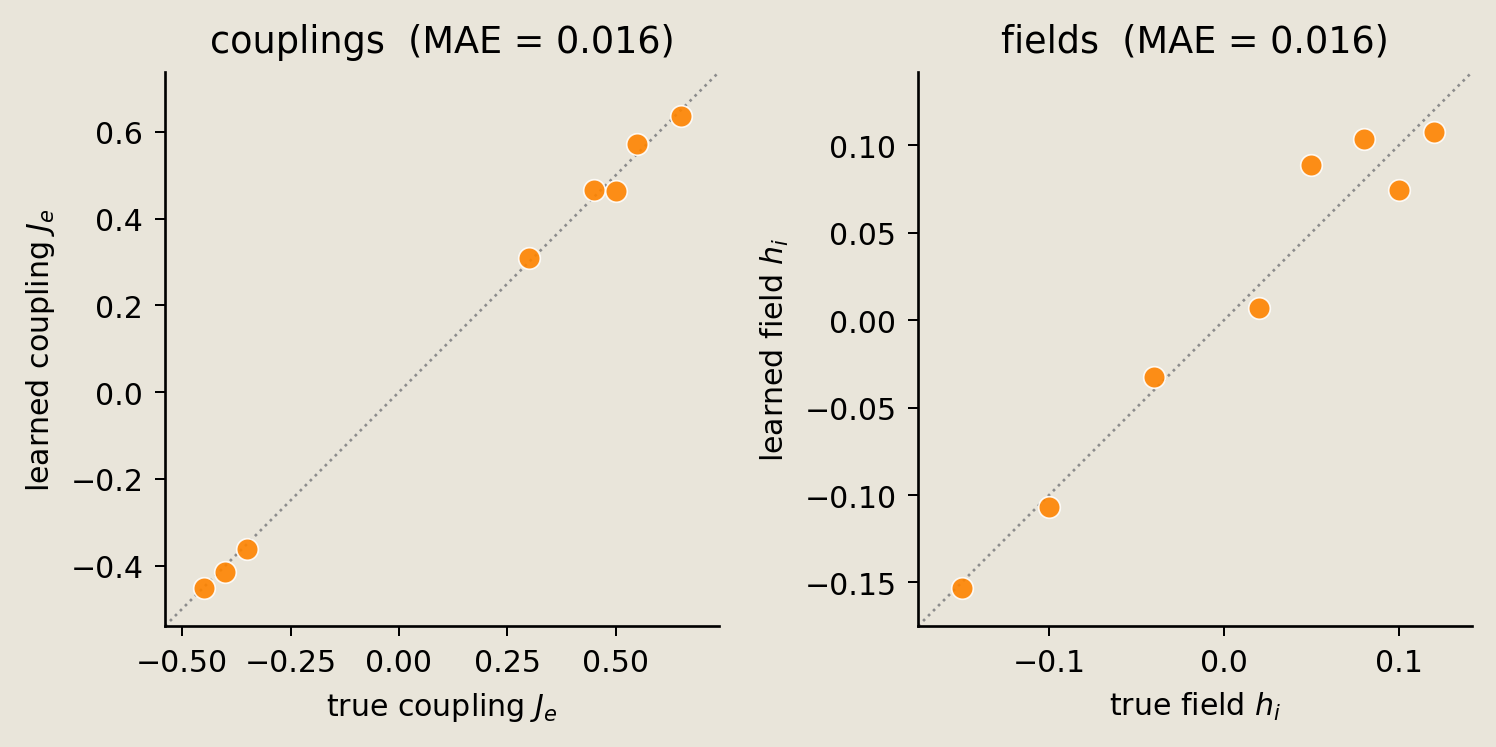

In [19]:
fig = P_samp.plot_pcd_recovery(J_true=J_true, J=J, h_true=h_true, h=h)
savefig(fig, "06_pcd_recovery")

Both panels hug the diagonal to within the printed maxima of 0.0373 for the couplings and 0.0386 for the fields, so this host-only fit recovered the full parameter set well inside the 0.05 tolerance.

## Verification

Each quantitative claim was asserted where it was made, so the closing cell reprints the whole set in one place:

In [20]:
print("all checks passed")
print(f"  chromatic Gibbs TV   = {tv_distance:.4f}  (< 0.08)")
print(f"  host PISING-matrix TV   = {pising_tv:.4f}")
print(f"  max |J - J_true|     = {np.max(np.abs(J - J_true)):.4f}")
print(f"  max |h - h_true|     = {np.max(np.abs(h - h_true)):.4f}")

all checks passed
  chromatic Gibbs TV   = 0.0634  (< 0.08)
  host PISING-matrix TV   = 0.4020
  max |J - J_true|     = 0.0373
  max |h - h_true|     = 0.0386


## Conclusion

We compared the exact ring law, Torx chromatic Gibbs, a host walk over Torx-generated `PISING` matrices, and a host-trained Ising model.

- The ideal per-site identity uses `PReset(∞)` then `PNOT`. The executable probe uses finite reset strength 12, while the ring manually supplies zero and runs only `PNOT`.
- The two-color ring sweep runs every site draw through Torx and reproduces the exact Boltzmann distribution to total variation 0.0634, inside the 0.08 bound we asserted.
- The host `PISING` matrix walker reaches only 0.4020 because each two-spin matrix omits live external-neighbor energy and therefore need not satisfy detailed balance for the full ring.
- Host-only persistent contrastive divergence recovers the couplings and fields to within 0.05 in 300 steps, with worst-case errors of 0.0373 and 0.0386.

Next, [`07_discrete_diffusion.ipynb`](07_discrete_diffusion.ipynb) uses `PNOT` gates for posterior per-pixel denoising, and [`08_stochastic_convolutional_networks.ipynb`](08_stochastic_convolutional_networks.ipynb) carries stochastic primitives into a convolutional network.

## References

1. <span id="ref-ackley"></span>Ackley, D.H., Hinton, G.E., Sejnowski, T.J. 1985. [*A learning algorithm for Boltzmann machines*](https://www.cs.toronto.edu/~hinton/absps/cogscibm.pdf). Cognitive Science 9(1), 147-169.
2. <span id="ref-tieleman"></span>Tieleman, T. 2008. [*Training restricted Boltzmann machines using approximations to the likelihood gradient*](https://www.cs.toronto.edu/~tijmen/pcd/pcd.pdf). ICML 2008, 1064-1071.